### Notebook - Table of Content

1. [**Importing necessary libraries**](#1.-Importing-necessary-libraries)   
2. [**Loading data**](#2.-Loading-data)
3. [**Data preprocessing**](#3.-Data-preprocessing)  
    3.1 [**Removing all the records with Score = 3**](#3.1-Removing-all-the-records-with-Score-=-3)   
    3.2 [**Defining sentiments based on score values**](#3.2-Defining-sentiments-based-on-score-values)   
    3.3 [**Checking for duplicate records**](#3.3-Checking-for-duplicate-records)   
    3.4 [**Checking Data consistency of HelpfulnessNumerator and HelpfulnessDenominator feature**](#3.4-Checking-Data-consistency-of-HelpfulnessNumerator-and-HelpfulnessDenominator-feature)  
    3.5 [**Checking for class imbalance**](#3.5-Checking-for-class-imbalance)  
4. [**Text preprocessing**](#4.-Text-preprocessing)  
5. [**Splitting into train and test set with 80:20 ratio**](#5.-Splitting-into-train-and-test-set-with-80:20-ratio)
6. [**Model Building**](#6.-Model-Building)   
    6.1 [**Fitting LSTM with Embedding layer**](#6.1-Fitting-LSTM-with-Embedding-layer)  
    6.2 [**Evaluating model performance on test data**](#6.2-Evaluating-model-performance-on-test-data)  

**Additional NOTE**

If you are interested in learning or exploring more about importance of feature selection in machine learning, then refer to my below blog offering.

https://www.analyticsvidhya.com/blog/2020/10/a-comprehensive-guide-to-feature-selection-using-wrapper-methods-in-python/

### 1. Importing necessary libraries

### 4. Text preprocessing

In this step, following operations are performed on the review text

* Removing website links
* Removing html tags
* Decontracting(expanding from the original form)
* Removing the words with numeric digits
* Removing non-word characters
* Converting to lower case
* Removing stop words
* Performing Lemmatization

### 5. Splitting into train and test set with 80:20 ratio

### 6. Model Building

#### 6.1 Fitting LSTM with Embedding layer

#### 6.2 Evaluating model performance on test data

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.9 MB/s eta 0:00:00


In [1]:

import kagglehub
snap_amazon_fine_food_reviews_path = kagglehub.dataset_download('snap/amazon-fine-food-reviews')



### 1. Importing necessary libraries
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import re
from bs4 import BeautifulSoup
from tqdm import tqdm
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation, GRU, Flatten
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Convolution1D
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers
from tensorflow.keras.preprocessing.text import Tokenizer

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Data source import complete.


In [2]:

"""### 2. Loading data"""

# Adjust the path based on KaggleHub download location
df = pd.read_csv(f"{snap_amazon_fine_food_reviews_path}/Reviews.csv")
print("Size of the data : ", df.shape)

df.head()

"""### 3. Data preprocessing

#### 3.1 Removing all the records with Score = 3
"""

df_filtered = df[df["Score"] != 3]
df_filtered.shape

"""#### 3.2 Defining sentiments based on score values"""

df_filtered["Score"] = df_filtered["Score"].apply(lambda x: 1 if x > 3 else 0)

"""#### 3.3 Checking for duplicate records"""

sorted_data = df_filtered.sort_values('ProductId', kind='quicksort', na_position='last')

final_df = sorted_data.drop_duplicates(subset={"UserId", "ProfileName", "Time", "Text"}, keep='first', inplace=False)
final_df.shape

"""#### 3.4 Checking Data consistency of HelpfulnessNumerator and HelpfulnessDenominator feature"""

final_df = final_df[final_df["HelpfulnessNumerator"] <= final_df["HelpfulnessDenominator"]]
final_df.shape


Size of the data :  (568454, 10)


(364171, 10)

In [3]:
"""#### 3.5 Checking for class imbalance"""

final_df['Score'].value_counts()

plt.figure(figsize=(10, 7))
sns.countplot(final_df['Score'])
plt.title("Bar plot of sentiments")
plt.show()



KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d6035308720> (for post_execute):


KeyboardInterrupt: 

Exception ignored in: <function _xla_gc_callback at 0x7d5fbcd3f7e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


Error in callback <function flush_figures at 0x7d60354d2200> (for post_execute):


KeyboardInterrupt: 

In [4]:
def decontract(text):
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    return text

In [5]:
# Set of custom stop words
stop_words = set(['br', 'the', 'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've",\
                  "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', \
                  'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their',\
                  'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', \
                  'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', \
                  'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', \
                  'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after',\
                  'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further',\
                  'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',\
                  'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', \
                  's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', \
                  've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',\
                  "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',\
                  "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", \
                  'won', "won't", 'wouldn', "wouldn't"])

lemmatizer = WordNetLemmatizer()

In [6]:
def preprocess_text(review):
    review = re.sub(r"http\S+", "", review)             # removing website links
    review = BeautifulSoup(review, 'lxml').get_text()   # removing html tags
    review = decontract(review)                         # decontracting
    review = re.sub("\S*\d\S*", "", review).strip()     # removing the words with numeric digits
    review = re.sub('[^A-Za-z]+', ' ', review)          # removing non-word characters
    review = review.lower()                             # converting to lower case
    review = [word for word in review.split(" ") if not word in stop_words] # removing stop words
    review = [lemmatizer.lemmatize(token, "v") for token in review] # Lemmatization
    review = " ".join(review)
    review.strip()
    return review

In [9]:
final_df['Text'] = final_df['Text'].apply(lambda x: preprocess_text(x))

final_df['Text'].head()

,Text
150523,witty little book make son laugh loud recite c...
150505,grow read sendak book watch really rosie movie...
150506,fun way children learn months year learn poems...
150507,great little book read aloud nice rhythm well ...
150508,book poetry months year go month cute little p...


In [8]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [10]:
"""### 5. Splitting into train and test set with 80:20 ratio"""

train_df, test_df = train_test_split(final_df, test_size=0.2, random_state=42)
print("Training data size : ", train_df.shape)
print("Test data size : ", test_df.shape)


Training data size :  (291336, 10)
Test data size :  (72835, 10)


In [11]:
"""### 6. Model Building

#### 6.1 Fitting LSTM with Embedding layer
"""

top_words = 6000
tokenizer = Tokenizer(num_words=top_words)
tokenizer.fit_on_texts(train_df['Text'])
list_tokenized_train = tokenizer.texts_to_sequences(train_df['Text'])

max_review_length = 130
X_train = pad_sequences(list_tokenized_train, maxlen=max_review_length)
y_train = train_df['Score']

embedding_vector_length = 32
model = Sequential()
model.add(Embedding(top_words + 1, embedding_vector_length, input_length=max_review_length))
model.add(LSTM(100))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.fit(X_train, y_train, epochs=2, batch_size=64, validation_split=0.2)

Epoch 1/2
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.9028 - loss: 0.2479 - val_accuracy: 0.9271 - val_loss: 0.1835
Epoch 2/2
3642/3642 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9382 - loss: 0.1593 - val_accuracy: 0.9364 - val_loss: 0.1629


In [13]:
"""#### 6.2 Evaluating model performance on test data"""

list_tokenized_test = tokenizer.texts_to_sequences(test_df['Text'])
X_test = pad_sequences(list_tokenized_test, maxlen=max_review_length)
y_test = test_df['Score']
prediction = model.predict(X_test)
y_pred = (prediction > 0.5).astype(int)
print("Accuracy of the model : ", accuracy_score(y_test, y_pred))
print('F1-score: ', f1_score(y_test, y_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

2277/2277 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step
Accuracy of the model :  0.9382165167845129
F1-score:  0.9634562286828001
Confusion matrix:
[[ 9015  2346]
 [ 2154 59320]]


2277/2277 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step
Accuracy of the model :  0.9382165167845129
F1-score:  0.9634562286828001
Confusion matrix:
 [[ 9015  2346]
 [ 2154 59320]]


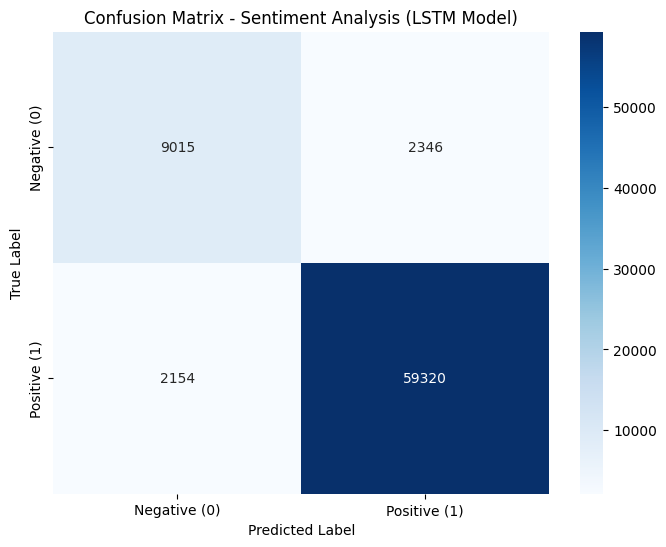

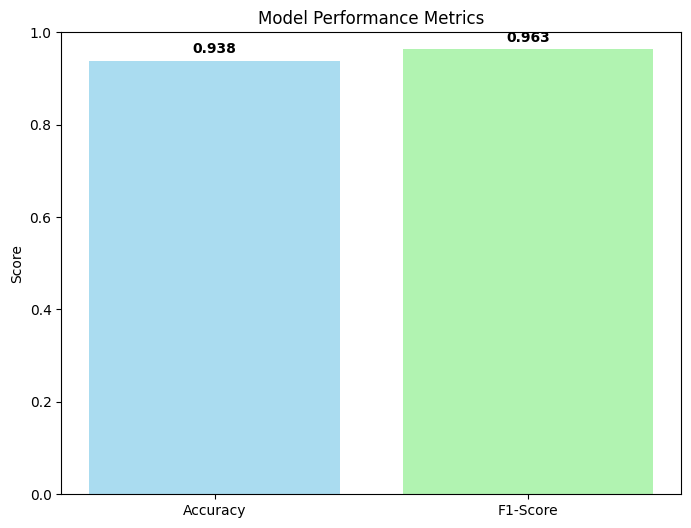

In [15]:
# Ensure necessary libraries are imported (add this if not already in your notebook)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Your original evaluation code
list_tokenized_test = tokenizer.texts_to_sequences(test_df['Text'])
X_test = pad_sequences(list_tokenized_test, maxlen=max_review_length)
y_test = test_df['Score']
prediction = model.predict(X_test)
y_pred = (prediction > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy of the model : ", accuracy)
print('F1-score: ', f1)
print('Confusion matrix:\n', cm)

# Visualization 1: Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Sentiment Analysis (LSTM Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualization 2: Bar Plot for Accuracy and F1-Score
metrics = ['Accuracy', 'F1-Score']
values = [accuracy, f1]

plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color=['skyblue', 'lightgreen'], alpha=0.7)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)  # Since these are percentages (0-1)

# Add value labels on top of bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.show()

In [19]:
import joblib

In [20]:
joblib.dump(model, 'model.pkl')

['model.pkl']

In [21]:
joblib.dump(tokenizer, 'tokenizer.pkl')

['tokenizer.pkl']

In [22]:
from IPython.display import FileLink
FileLink(r'model.pkl')

/content/model.pkl

In [23]:
FileLink(r'tokenizer.pkl')

/content/tokenizer.pkl

**Test Model


In [24]:
import numpy as np
import re
from bs4 import BeautifulSoup
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.utils import pad_sequences
import joblib

# Try to import load_model (for .h5 fallback)
try:
    from tensorflow.keras.models import load_model
    HAS_LOAD_MODEL = True
except ImportError:
    HAS_LOAD_MODEL = False
    print("Warning: TensorFlow/Keras not fully available. Model loading may fail.")

# Redefine preprocessing functions (exact same as training)
def decontract(text):
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    return text

# Custom stop words (exact same as training)
stop_words = set(['br', 'the', 'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've",\
                  "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', \
                  'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their',\
                  'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', \
                  'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', \
                  'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', \
                  'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after',\
                  'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further',\
                  'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',\
                  'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', \
                  's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', \
                  've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',\
                  "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',\
                  "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", \
                  'won', "won't", 'wouldn', "wouldn't"])

lemmatizer = WordNetLemmatizer()

def preprocess_text(review):
    review = re.sub(r"http\S+", "", review)             # removing website links
    review = BeautifulSoup(review, 'lxml').get_text()   # removing html tags
    review = decontract(review)                         # decontracting
    review = re.sub("\S*\d\S*", "", review).strip()     # removing the words with numeric digits
    review = re.sub('[^A-Za-z]+', ' ', review)          # removing non-word characters
    review = review.lower()                             # converting to lower case
    review = [word for word in review.split(" ") if not word in stop_words] # removing stop words
    review = [lemmatizer.lemmatize(token, "v") for token in review] # Lemmatization
    review = " ".join(review)
    review.strip()
    return review

# Load tokenizer (this should work)
try:
    tokenizer = joblib.load('tokenizer.pkl')
    print("Tokenizer loaded successfully!")
except FileNotFoundError:
    print("Error: 'tokenizer.pkl' not found. Upload it to the current directory.")
    raise
except Exception as e:
    print(f"Error loading tokenizer: {e}")
    raise

# Load model (try .pkl first, fallback to .h5)
model = None
try:
    # Attempt to load your .pkl (may fail for Keras models)
    model = joblib.load('model.pkl')
    print("Model loaded from 'model.pkl' successfully!")
except FileNotFoundError:
    print("Error: 'model.pkl' not found. Trying .h5 fallback...")
except Exception as e:
    print(f"Error loading 'model.pkl': {e}. This is common for Keras models. Using .h5 fallback...")

if model is None and HAS_LOAD_MODEL:
    try:
        model = load_model('lstm_sentiment_model.h5')
        print("Model loaded from 'lstm_sentiment_model.h5' successfully!")
    except FileNotFoundError:
        print("Error: 'lstm_sentiment_model.h5' not found. Please resave the model using model.save('lstm_sentiment_model.h5').")
        raise
    except Exception as e:
        print(f"Error loading .h5: {e}")
        raise

if model is None:
    raise ValueError("Model could not be loaded. Resave using the corrected code above.")

# Model parameters (match training)
top_words = 6000
max_review_length = 130

def predict_sentiment(text, threshold=0.5):
    """
    Predict sentiment for a given text.
    """
    processed_text = preprocess_text(text)
    if not processed_text.strip():
        return {'error': 'Text empty after preprocessing.'}

    tokenized = tokenizer.texts_to_sequences([processed_text])
    padded = pad_sequences(tokenized, maxlen=max_review_length)

    prediction = model.predict(padded, verbose=0)[0][0]  # Positive class probability
    label = 1 if prediction > threshold else 0
    sentiment = 'Positive' if label == 1 else 'Negative'

    return {
        'original_text': text,
        'preprocessed_text': processed_text,
        'probability_positive': float(prediction),
        'label': label,
        'sentiment': sentiment
    }

# Test with 3 inputs: Positive, Negative, Neutral
test_inputs = {
    'Positive': "This product is amazing! I love it and highly recommend.",
    'Negative': "Terrible quality, broke immediately. Waste of money.",
    'Neutral': "It's okay, nothing special but works fine."
}

print("\n=== Testing Model with 3 Inputs ===")
for category, text in test_inputs.items():
    print(f"\n--- Test: {category} ---")
    result = predict_sentiment(text)
    if 'error' in result:
        print(f"Error: {result['error']}")
    else:
        print(f"Original: {result['original_text']}")
        print(f"Preprocessed: {result['preprocessed_text']}")
        print(f"Probability (Positive): {result['probability_positive']:.4f}")
        print(f"Predicted: **{result['sentiment']}** (Label: {result['label']})")
    print("-" * 60)

Tokenizer loaded successfully!
Model loaded from 'model.pkl' successfully!

=== Testing Model with 3 Inputs ===

--- Test: Positive ---
Original: This product is amazing! I love it and highly recommend.
Preprocessed: product amaze love highly recommend 
Probability (Positive): 0.9999
Predicted: **Positive** (Label: 1)
------------------------------------------------------------

--- Test: Negative ---
Original: Terrible quality, broke immediately. Waste of money.
Preprocessed: terrible quality break immediately waste money 
Probability (Positive): 0.0017
Predicted: **Negative** (Label: 0)
------------------------------------------------------------

--- Test: Neutral ---
Original: It's okay, nothing special but works fine.
Preprocessed: okay nothing special work fine 
Probability (Positive): 0.4650
Predicted: **Negative** (Label: 0)
------------------------------------------------------------
